## 2. Data understanding/EDA

This section analyzes the COVID-19 dataset before preprocessing. The structure of the dataset is identified along with any potential data issues. Relationships between the variables that may affect the models are determined.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [33]:
df = pd.read_excel('CovidData.xlsx')

### Dataset Overview

In [34]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Number of observations: 1030724
Number of variables: 9


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030724 entries, 0 to 1030723
Data columns (total 9 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   Cough                1030724 non-null  int64
 1   Fever                1030724 non-null  int64
 2   Sore_Throat          1030724 non-null  int64
 3   Shortness_Of_Breath  1030724 non-null  int64
 4   Headache             1030724 non-null  int64
 5   Age_60_And_Above     979736 non-null   str  
 6   Sex                  1028123 non-null  str  
 7   Contact              1030724 non-null  int64
 8   Result               1030724 non-null  str  
dtypes: int64(6), str(3)
memory usage: 70.8 MB


In [36]:
df.head()

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
0,0,0,0,0,0,No,female,0,negative
1,0,0,0,0,0,No,female,0,negative
2,1,0,0,0,0,No,female,0,negative
3,0,0,0,0,0,No,male,0,negative
4,0,0,0,0,0,No,female,0,negative


In [37]:
df.describe(include='all')

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
count,1.030724e+06,1.030724e+06,1.030724e+06,1.030724e+06,1.030724e+06,979736,1028123,1.030724e+06,1030724
unique,NaN,NaN,NaN,NaN,NaN,2,2,NaN,2
top,NaN,NaN,NaN,NaN,NaN,No,female,NaN,negative
freq,NaN,NaN,NaN,NaN,NaN,849307,528254,NaN,925290
mean,2.680252e-02,2.717604e-02,8.983006e-03,2.716537e-03,1.888963e-02,NaN,NaN,6.311583e-02,NaN
std,1.615059e-01,1.625962e-01,9.435211e-02,5.204959e-02,1.361354e-01,NaN,NaN,2.431713e-01,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN


### Missing Values

In [38]:
# Count missing values in every column
missing = df.isnull().sum()

In [39]:
# Display only columns with missing values
missing[missing > 0]

Age_60_And_Above    50988
Sex                  2601
dtype: int64

In [40]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percent Missing": missing_percent
})

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percent Missing
Age_60_And_Above,50988,4.946814
Sex,2601,0.252347


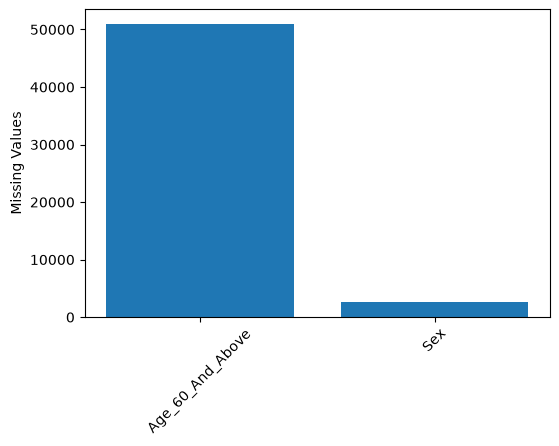

In [41]:
missing_df = missing_df[missing_df["Missing Values"] > 0]

plt.figure(figsize=(6,4))
plt.bar(missing_df.index, missing_df["Missing Values"])
plt.ylabel("Missing Values")
plt.xticks(rotation=45)
plt.savefig("Figure1.png", dpi=300, bbox_inches="tight")
plt.show()

The following two variables contain values with missing values: **Age_60_And_Above** and **Sex**. The **Age_60_And_Above** variable has **50,988 missing** data points (4.95%). **Sex** has **2,601 missing** data points (0.25%). All other columns contain no missing data.

Since the amount of missing values is proportional low to the overall dataset, these values can be dropped during the data preparation stage without dramatically reducing the size of the overall dataset.

### Target Variable

The target variable is checked to see whether the dataset is balanced between positive and negative COVID-19 test results. Balance is important because imbalanced datasets can negatively impact the performance of models.

In [42]:
# Count observations for each COVID-19 test result
result_counts = df["Result"].value_counts()

result_counts

Result
negative    925290
positive    105434
Name: count, dtype: int64

In [43]:
# Percentage of each class
result_percent = df["Result"].value_counts(normalize=True) * 100

result_percent.round(2)

Result
negative    89.77
positive    10.23
Name: proportion, dtype: float64

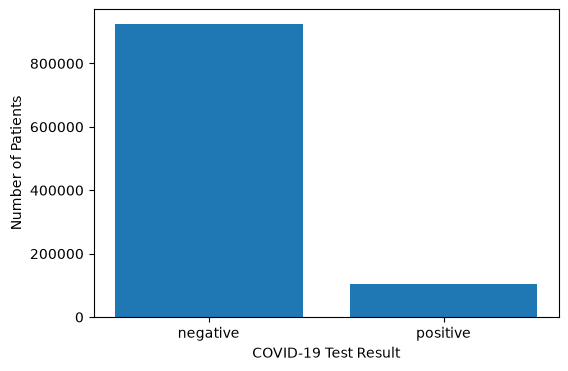

In [44]:
plt.figure(figsize=(6,4))

plt.bar(result_counts.index, result_counts.values)

#plt.title("Distribution of COVID-19 Test Results")
plt.xlabel("COVID-19 Test Result")
plt.ylabel("Number of Patients")
plt.savefig("Figure2.png", dpi=300, bbox_inches="tight")
plt.show()

The target variable is not distributed evenly. 876,547 (89.47%) are negative COVID-19 test results, while 103,189 (10.53%) are positive. This showcases a class imbalance. Negative cases occur more often than positive cases.

Because there is an imbalance, accuracy by itself may not provide a complete picture of model performance.

### Symptom Frequencies

The symptoms are binary indicators where a value of 1 correlates to the symptom having been reported and 0 indicates it was not reported.

In [45]:
# List of symptom variables
symptom_cols = [
    "Cough",
    "Fever",
    "Sore_Throat",
    "Shortness_Of_Breath",
    "Headache"
]

In [46]:
# Count patients reporting each symptom
symptom_counts = df[symptom_cols].sum().sort_values(ascending=False)

symptom_counts

Fever                  28011
Cough                  27626
Headache               19470
Sore_Throat             9259
Shortness_Of_Breath     2800
dtype: int64

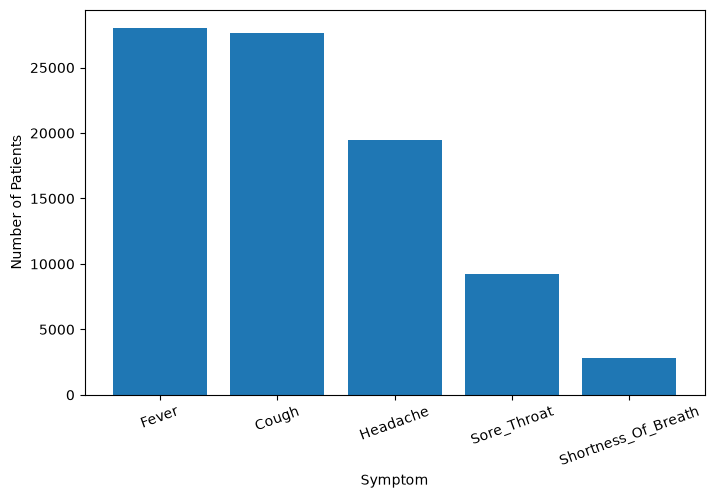

In [47]:
plt.figure(figsize=(8,5))

plt.bar(symptom_counts.index, symptom_counts.values)

#plt.title("Frequency of Reported COVID-19 Symptoms")
plt.xlabel("Symptom")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.savefig("Figure3.png", dpi=300, bbox_inches="tight")
plt.show()

From the reported symptoms, fever (27,367) was the most frequently reported. Shortness of breaths (2,740) was the least reported symptom.

The frequency of a symptom by itself does not indicate a positive COVID-19 diagnosis; therefore, the next stage of the EDA looks at the relationship between each symptom and the COVID-19 test result.

### Relationship Between Symptoms and Test Results

This section looks at the relationship between each symptom and the COVID-19 test result by comparing the proportion of positive test results among individuals with and without each symptom.

In [48]:
symptom_positive = []

for symptom in symptom_cols:
    positive_rate = (
        df[df[symptom] == 1]["Result"]
        .eq("positive")
        .mean() * 100
    )

    symptom_positive.append(positive_rate)

symptom_df = pd.DataFrame({
    "Symptom": symptom_cols,
    "Positive Rate (%)": symptom_positive
})

symptom_df = symptom_df.sort_values(
    by="Positive Rate (%)",
    ascending=False
)

symptom_df

,Symptom,Positive Rate (%)
4,Headache,86.147920
3,Shortness_Of_Breath,85.035714
2,Sore_Throat,84.987580
1,Fever,67.469923
0,Cough,58.010570


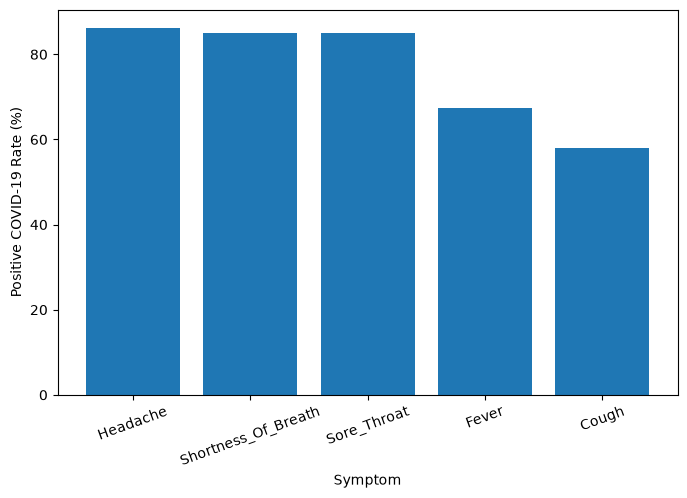

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    symptom_df["Symptom"],
    symptom_df["Positive Rate (%)"]
)

#plt.title("Positive COVID-19 Rate by Reported Symptom")
plt.xlabel("Symptom")
plt.ylabel("Positive COVID-19 Rate (%)")
plt.xticks(rotation=20)
plt.savefig("Figure4.png", dpi=300, bbox_inches="tight")
plt.show()

Patients reporting **headache** had the highest positive test rate (86.09%). Although more than half of the individuals reported having a cough (58.33%), **cough** was the lowest positive rate among the symptoms assessed. This suggest that not all symptoms equally lead to a positive test result.

### Contact vs. Test Result

Individuals who have had contact with infected persons are expected to have a higher probability of testing positive.

In [50]:
contact_result = pd.crosstab(
    df["Contact"],
    df["Result"],
    normalize="index"
) * 100

contact_result

Result,negative,positive
Contact,,
0,93.174783,6.825217
1,39.243717,60.756283


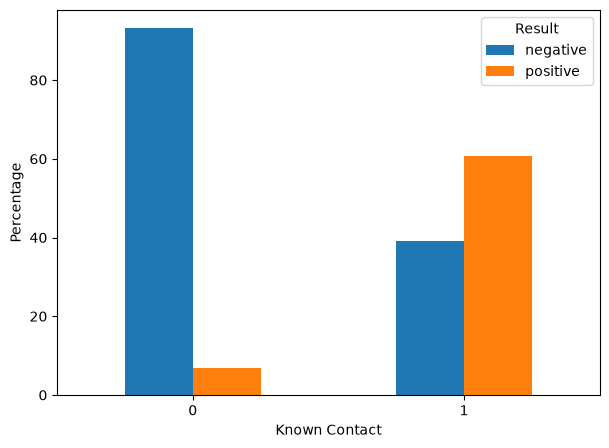

In [51]:
contact_result.plot(
    kind="bar",
    figsize=(7,5)
)

#plt.title("COVID-19 Test Result by Contact History")
plt.ylabel("Percentage")
plt.xlabel("Known Contact")
plt.xticks(rotation=0)
plt.savefig("Figure5.png", dpi=300, bbox_inches="tight")
plt.show()

There is a strong association between exposure and infection. Among individuals with **no contact**, **93%** tested **negative**, while **7%** tested **positive**. Individuals with **known contact**, **61%** tested positive and **39%** tested **negative**. This suggests that contact with a person confirmed to have COVID-19 is a strong predictor of a positive test result.

### Correlation Analysis

A correlation matrix is used to examine the relationships among the predictor variables.

In [52]:
# Create a temporary copy
temp = df.copy()

In [53]:
# Convert the target variable to numeric
temp["Result_Num"] = temp["Result"].map({
    "negative": 0,
    "positive": 1
})

In [54]:
# Select variables for correlation analysis
corr_cols = [
    "Cough",
    "Fever",
    "Sore_Throat",
    "Shortness_Of_Breath",
    "Headache",
    "Age_60_And_Above",
    "Contact",
    "Result_Num"
]

In [55]:
# Convert Age_60_And_Above from Yes/No to 1/0
temp["Age_60_And_Above"] = temp["Age_60_And_Above"].map({
    "Yes": 1,
    "No": 0
})

In [56]:
# Drop rows with missing values in the selected columns
corr_data = temp[corr_cols].dropna()

In [57]:
# Compute correlation matrix
corr_matrix = corr_data.corr()

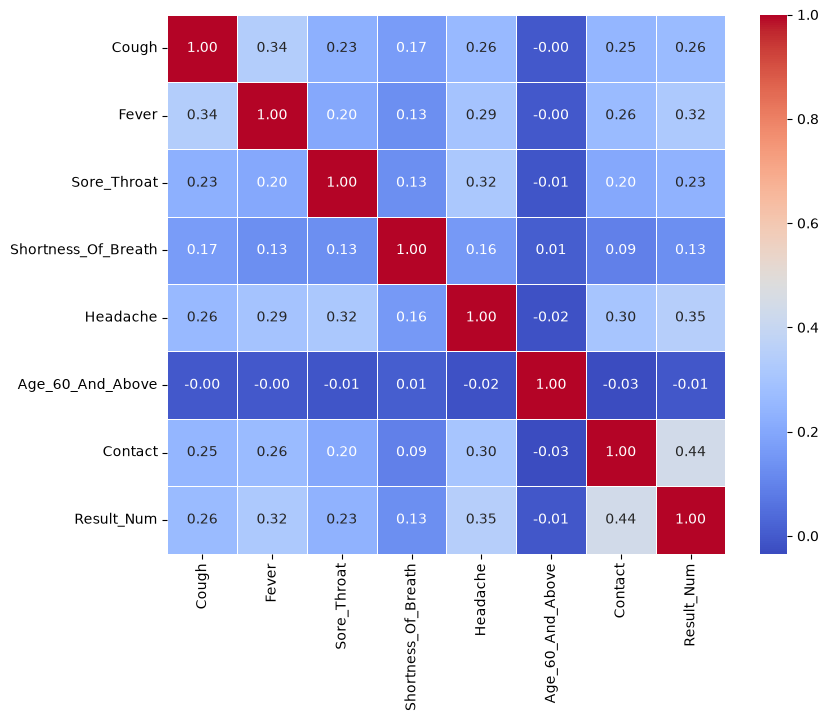

In [58]:
# Plot heatmap
plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

#plt.title("Correlation Matrix of Predictor Variables and COVID-19 Test Result")
plt.savefig("Figure6.png", dpi=300, bbox_inches="tight")
plt.show()

The correlation matrix shows that most predictor variables have weak positive correlations with one another, suggesting that each variable uniquely correlates to a positive test result. The strongest relationship with the target variable is **Contact** (r = 0.44). This indicates that contact with an infected individual is the strongest predictor of a positive COVID-19 test result. From the symptoms, **Headache** (r = 0.35) and **Fever** (r = 0.32) have the strongest correlations with a positive test result. Since no pair has a strong correlation, multicollinearity is unlikely to be a factor for the models developed.

### Age (60+) vs. Test Result

This section looks at the relationship between age and COVID-19 test results. This helps determine if age is associated with an increased chance of testing positive for COVID-19.

In [59]:
age_result = pd.crosstab(
    df["Age_60_And_Above"],
    df["Result"],
    normalize="index"
) * 100

age_result

Result,negative,positive
Age_60_And_Above,,
No,89.387819,10.612181
Yes,89.987656,10.012344


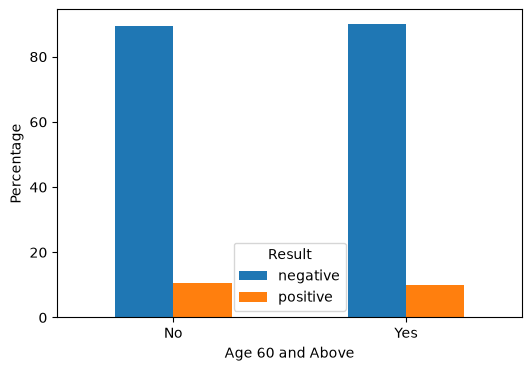

In [60]:
age_result.plot(
    kind="bar",
    figsize=(6,4)
)

#plt.title("COVID-19 Test Result by Age Group")
plt.xlabel("Age 60 and Above")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.savefig("Figure7.png", dpi=300, bbox_inches="tight")
plt.show()

The relationship between age and test results shows no meaningful difference between individuals over and under sixty. About **10.61%** of individuals under sixty tested positive. About **10.01%** of individuals sixty and above tested positive. This suggests that the **Age_60_And_Above** variable has little connection with positive test results.

### Sex vs. Test Results

This section looks at the relationship between an individual's sex and test results. This helps determine if sex is associated with a positive test result and if it may be a point of influence for the classification models later developed.

In [61]:
sex_result = pd.crosstab(
    df["Sex"],
    df["Result"],
    normalize="index"
) * 100

sex_result

Result,negative,positive
Sex,,
female,90.510815,9.489185
male,88.996917,11.003083


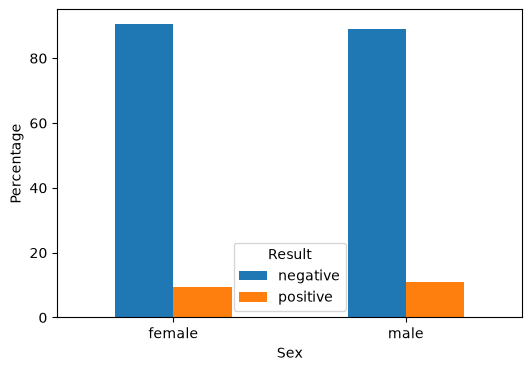

In [62]:
sex_result.plot(
    kind="bar",
    figsize=(6,4)
)

#plt.title("COVID-19 Test Result by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.savefig("Figure8.png", dpi=300, bbox_inches="tight")
plt.show()

The relationship between sex and test results shows a small difference in positive test rates between male and female individuals. About **11.32% of males tested positive** for COVID-19, while **9.78% of females** tested positive for COVID-19. Although males were more likely to test positive compared to females, the difference between the two is small. This suggests that sex may only moderately influence the predictive models. 

## Data preparation

This section prepares the dataset for modeling. Categorical variables are converted into binary numeric values. Missing values are removed and the data is partitioned into training/testing sets.

### Missing Data Handling

Missing values are removed from the Age_60_And_Above and Sex variables.

In [63]:
# Create a copy so the original dataframe remains unchanged
clean_df = df.copy()

In [64]:
# Display the dataset size before removing missing values
print(f"Rows before cleaning: {clean_df.shape[0]:,}")

Rows before cleaning: 1,030,724


In [65]:
# Remove rows with missing values in the demographic variables
clean_df = clean_df.dropna(
    subset=["Age_60_And_Above", "Sex"]
).copy()

In [66]:
# Display the dataset size after removing missing values
print(f"Rows after cleaning: {clean_df.shape[0]:,}")
print(f"Rows removed: {df.shape[0] - clean_df.shape[0]:,}")

Rows after cleaning: 978,493
Rows removed: 52,231


In [67]:
# Confirm that the cleaned dataframe contains no missing values
clean_df.isna().sum()

Cough                  0
Fever                  0
Sore_Throat            0
Shortness_Of_Breath    0
Headache               0
Age_60_And_Above       0
Sex                    0
Contact                0
Result                 0
dtype: int64

### Variable Encoding

The Age_60_And_Above, Sex, and Result variables are text variable; thereore, they must be converted into numeric values before creating the models. Yes values are encoded as 1. Positive values are encoded as 1. Male values are encoded as 1. Alternate values for these categories are encoded as 0.

In [68]:
# Convert text-based binary variables to numeric values for age
clean_df["Age_60_And_Above"] = clean_df["Age_60_And_Above"].map({
    "Yes": 1,
    "No": 0
})

In [69]:
# Convert text-based binary variables to numeric values for sex
clean_df["Sex"] = clean_df["Sex"].map({
    "male": 1,
    "female": 0
})

In [70]:
# Convert text-based binary variables to numeric values for final result
clean_df["Result"] = clean_df["Result"].map({
    "positive": 1,
    "negative": 0
})

In [71]:
# Verify encoded values
for column in ["Age_60_And_Above", "Sex", "Result"]:
    print(f"{column}: {sorted(clean_df[column].unique())}")

Age_60_And_Above: [np.int64(0), np.int64(1)]
Sex: [np.int64(0), np.int64(1)]
Result: [np.int64(0), np.int64(1)]
